<a href="https://colab.research.google.com/github/JaySharma424/Deep-Learning-for-computer-vision/blob/main/DeepFER_Facial_Emotion_Recognition_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepFER — Facial Emotion Recognition Using Deep Learning

**Colab-ready end-to-end project notebook**

This notebook implements the DeepFER pipeline described in the project brief:

- Seven-class facial-expression classification: **angry, sad, happy, fear, neutral, disgust, surprise**
- Dataset integrity checks and basic cleaning
- **Basic image preprocessing only:** RGB conversion + resize to 224×224
- Simple training augmentation: horizontal flip + small rotation
- **EfficientNetB0 transfer learning + fine-tuning**
- Class-weighted training for class imbalance
- Training/validation/test evaluation with accuracy, precision, recall, F1-score
- Confusion matrix, misclassification examples, and Grad-CAM interpretability
- Clear visual exploration of **different images from all seven classes**
- **Epoch-by-epoch training vs validation accuracy line chart**
- Exported model and a **Streamlit UI** for image upload and camera capture

> **Note:** The model predicts visible facial-expression categories. It does not diagnose mental health or determine a person's private emotional state.


## 1. Environment setup

Run this cell first. Google Colab normally includes TensorFlow already; the conditional install keeps the notebook portable.


In [1]:
# Install the packages required by the notebook and Streamlit UI.
import sys, subprocess, importlib.util, os, random, json, zipfile, shutil, hashlib, io, time
from pathlib import Path

required = {
    "streamlit": "streamlit",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "PIL": "pillow"
}

missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

print("Environment ready.")


Environment ready.


## 2. Upload the dataset ZIP

Upload the dataset ZIP supplied for this project. The notebook automatically searches inside the extracted folder for the directory containing the seven emotion folders.

Expected dataset structure is similar to:

```text
.../train/
    angry/
    disgust/
    fear/
    happy/
    neutral/
    sad/
    surprise/
```


In [2]:
from google.colab import files

uploaded = files.upload()
zip_files = [name for name in uploaded.keys() if name.lower().endswith(".zip")]

if not zip_files:
    raise FileNotFoundError("Please upload the DeepFER dataset as a .zip file.")

ZIP_PATH = zip_files[0]
print(f"Using dataset archive: {ZIP_PATH}")


Saving Face Emotion Recognition Dataset.zip to Face Emotion Recognition Dataset.zip
Using dataset archive: Face Emotion Recognition Dataset.zip


In [3]:
# Extract the ZIP archive.
EXTRACT_ROOT = Path("/content/deepfer_extracted")

if EXTRACT_ROOT.exists():
    shutil.rmtree(EXTRACT_ROOT)
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_ROOT)

EXPECTED_CLASSES = [
    "angry", "disgust", "fear", "happy",
    "neutral", "sad", "surprise"
]

train_candidates = []
for p in EXTRACT_ROOT.rglob("train"):
    if p.is_dir():
        child_dirs = {x.name.lower() for x in p.iterdir() if x.is_dir()}
        if set(EXPECTED_CLASSES).issubset(child_dirs):
            train_candidates.append(p)

if not train_candidates:
    raise FileNotFoundError(
        "Could not locate a 'train' directory containing all seven emotion classes."
    )

DATA_DIR = train_candidates[0]

print("Detected dataset directory:", DATA_DIR)
print("Class folders:", sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()]))


Detected dataset directory: /content/deepfer_extracted/images/train
Class folders: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 3. Reproducibility and project configuration

The split is intentionally stratified because the supplied dataset is imbalanced, especially for the **disgust** class.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from IPython.display import clear_output

from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

ImageFile.LOAD_TRUNCATED_IMAGES = False

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 64 if tf.config.list_physical_devices("GPU") else 32
HEAD_EPOCHS = 5
FINETUNE_EPOCHS = 5
AUTOTUNE = tf.data.AUTOTUNE

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Batch size:", BATCH_SIZE)


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Batch size: 64


## 4. Data integrity and cleaning

This scan:

1. ignores non-image files,
2. checks that every image can be decoded,
3. records image dimensions,
4. computes an exact SHA-1 hash,
5. detects exact duplicate files,
6. flags unknown class folders.

Duplicate handling:
- duplicates with the **same label**: keep one copy;
- duplicate image content with **conflicting labels**: drop the conflicting duplicate group to prevent label leakage/ambiguity.

The resulting clean table is used for all subsequent splits.


In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def scan_dataset(data_dir: Path, expected_classes):
    records = []
    ignored_files = []
    corrupt_files = []
    unknown_class_dirs = []

    for class_dir in sorted(data_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name.lower()
        if class_name not in expected_classes:
            unknown_class_dirs.append(str(class_dir))
            continue

        for file_path in sorted(class_dir.rglob("*")):
            if not file_path.is_file():
                continue

            if file_path.suffix.lower() not in IMAGE_EXTENSIONS:
                ignored_files.append(str(file_path))
                continue

            try:
                raw = file_path.read_bytes()
                sha1 = hashlib.sha1(raw).hexdigest()

                with Image.open(io.BytesIO(raw)) as img:
                    img.load()
                    width, height = img.size
                    mode = img.mode

                records.append({
                    "path": str(file_path),
                    "label": class_name,
                    "width": width,
                    "height": height,
                    "mode": mode,
                    "sha1": sha1
                })
            except Exception as exc:
                corrupt_files.append({
                    "path": str(file_path),
                    "error": str(exc)
                })

    return (
        pd.DataFrame(records),
        ignored_files,
        corrupt_files,
        unknown_class_dirs
    )

df_all, ignored_files, corrupt_files, unknown_dirs = scan_dataset(
    DATA_DIR, EXPECTED_CLASSES
)

print(f"Valid images scanned : {len(df_all):,}")
print(f"Corrupt/unreadable   : {len(corrupt_files):,}")
print(f"Ignored non-images   : {len(ignored_files):,}")
print(f"Unknown class dirs   : {len(unknown_dirs):,}")

if corrupt_files:
    display(pd.DataFrame(corrupt_files).head())

if unknown_dirs:
    print("Unknown directories:")
    for item in unknown_dirs:
        print(" -", item)


Valid images scanned : 28,821
Corrupt/unreadable   : 0
Ignored non-images   : 0
Unknown class dirs   : 0


In [6]:
# Exact duplicate analysis and clean dataset construction.
duplicate_groups = df_all.groupby("sha1").size()
duplicate_hashes = duplicate_groups[duplicate_groups > 1].index

duplicate_rows = df_all[df_all["sha1"].isin(duplicate_hashes)].copy()

# Keep one copy when all duplicate files have the same class.
keep_rows = []
conflicting_hashes = []

for sha1, group in df_all.groupby("sha1", sort=False):
    if len(group) == 1:
        keep_rows.append(group.iloc[0])
        continue

    if group["label"].nunique() == 1:
        keep_rows.append(group.iloc[0])
    else:
        conflicting_hashes.append(sha1)

clean_df = pd.DataFrame(keep_rows).reset_index(drop=True)

print(f"Exact duplicate image groups : {len(duplicate_hashes):,}")
print(f"Conflicting duplicate groups : {len(conflicting_hashes):,}")
print(f"Clean images retained         : {len(clean_df):,}")

if conflicting_hashes:
    print("Conflicting duplicate groups were removed to avoid ambiguous labels.")

clean_df = clean_df[clean_df["label"].isin(EXPECTED_CLASSES)].copy()

# Basic dimension sanity check
clean_df["pixels"] = clean_df["width"] * clean_df["height"]

print("\nDimension summary:")
display(clean_df[["width", "height"]].describe())


Exact duplicate image groups : 1,055
Conflicting duplicate groups : 45
Clean images retained         : 27,515
Conflicting duplicate groups were removed to avoid ambiguous labels.

Dimension summary:


,width,height
count,27515.0,27515.0
mean,48.0,48.0
std,0.0,0.0
min,48.0,48.0
25%,48.0,48.0
50%,48.0,48.0
75%,48.0,48.0
max,48.0,48.0


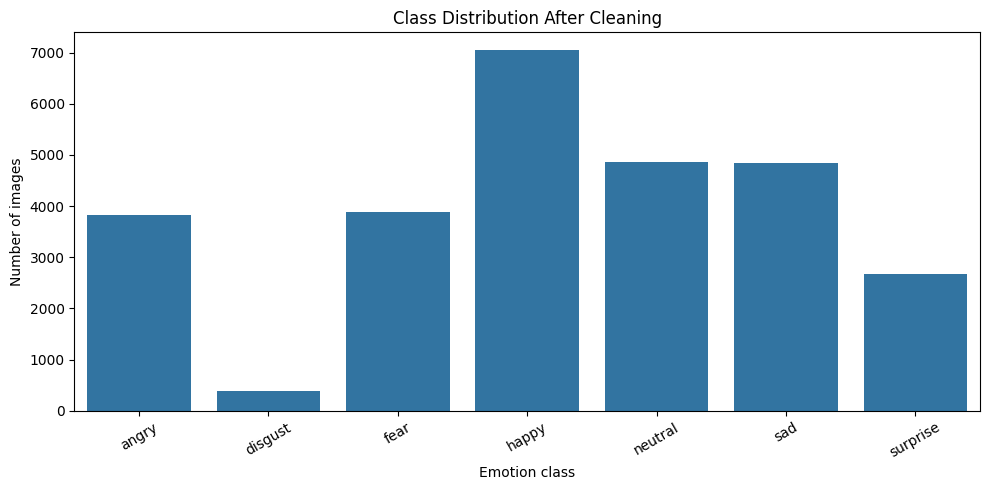

,count
label,
angry,3825
disgust,377
fear,3893
happy,7042
neutral,4866
sad,4831
surprise,2681


In [7]:
# Class distribution after cleaning.
class_counts = clean_df["label"].value_counts().reindex(EXPECTED_CLASSES)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution After Cleaning")
plt.xlabel("Emotion class")
plt.ylabel("Number of images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(class_counts.rename("count").to_frame())


### Dataset-quality interpretation

The supplied ZIP contains a **single training folder**, so the notebook creates independent stratified train/validation/test subsets rather than treating the source folder as three pre-existing splits. This prevents evaluation from depending on an unavailable official test folder.

The imbalance is handled with **class weights** during training rather than deleting large numbers of majority-class images.


## 5. Stratified train/validation/test split

We use:

- **70% training**
- **15% validation**
- **15% test**

The test set remains untouched until final evaluation.


In [8]:
# Stratified 70/15/15 split.
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    stratify=clean_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

for frame in (train_df, val_df, test_df):
    frame.reset_index(drop=True, inplace=True)

print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "validation": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts()
}).reindex(EXPECTED_CLASSES)

display(split_summary)


Train: 19,260
Val  : 4,127
Test : 4,128


,train,validation,test
label,,,
angry,2677,574,574
disgust,264,57,56
fear,2725,584,584
happy,4929,1056,1057
neutral,3406,730,730
sad,3382,724,725
surprise,1877,402,402


In [9]:
# Compute balanced class weights.
label_to_id = {label: idx for idx, label in enumerate(EXPECTED_CLASSES)}

y_train = train_df["label"].map(label_to_id).values
class_ids = np.arange(len(EXPECTED_CLASSES))

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=y_train
)
CLASS_WEIGHTS = {int(i): float(w) for i, w in zip(class_ids, weights)}

print("Class weights:")
for idx, label in enumerate(EXPECTED_CLASSES):
    print(f"{label:>9}: {CLASS_WEIGHTS[idx]:.3f}")


Class weights:
    angry: 1.028
  disgust: 10.422
     fear: 1.010
    happy: 0.558
  neutral: 0.808
      sad: 0.814
 surprise: 1.466


## 6. Basic image preprocessing and visualization

To keep the preprocessing simple and easy to explain in a project presentation, the pipeline only performs:

1. Read the image
2. Convert it to RGB
3. Resize it to **224×224**
4. Use simple augmentation during training: horizontal flip and small rotation

We also visualize different examples before model training so the dataset and class variability are easy to understand. EfficientNetB0 handles the input scaling expected by the pretrained network internally.


In [10]:
def decode_and_resize(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(frame, shuffle=False):
    paths = frame["path"].values
    labels = frame["label"].map(label_to_id).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(frame), 10000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print(f"Train images: {len(train_df):,}")
print(f"Validation images: {len(val_df):,}")
print(f"Test images: {len(test_df):,}")


Train images: 19,260
Validation images: 4,127
Test images: 4,128


### 6.1 Visualize different images from each emotion class

The grid below shows multiple randomly selected examples from **every class**. This makes class diversity, pose, lighting, and expression differences visible before training.


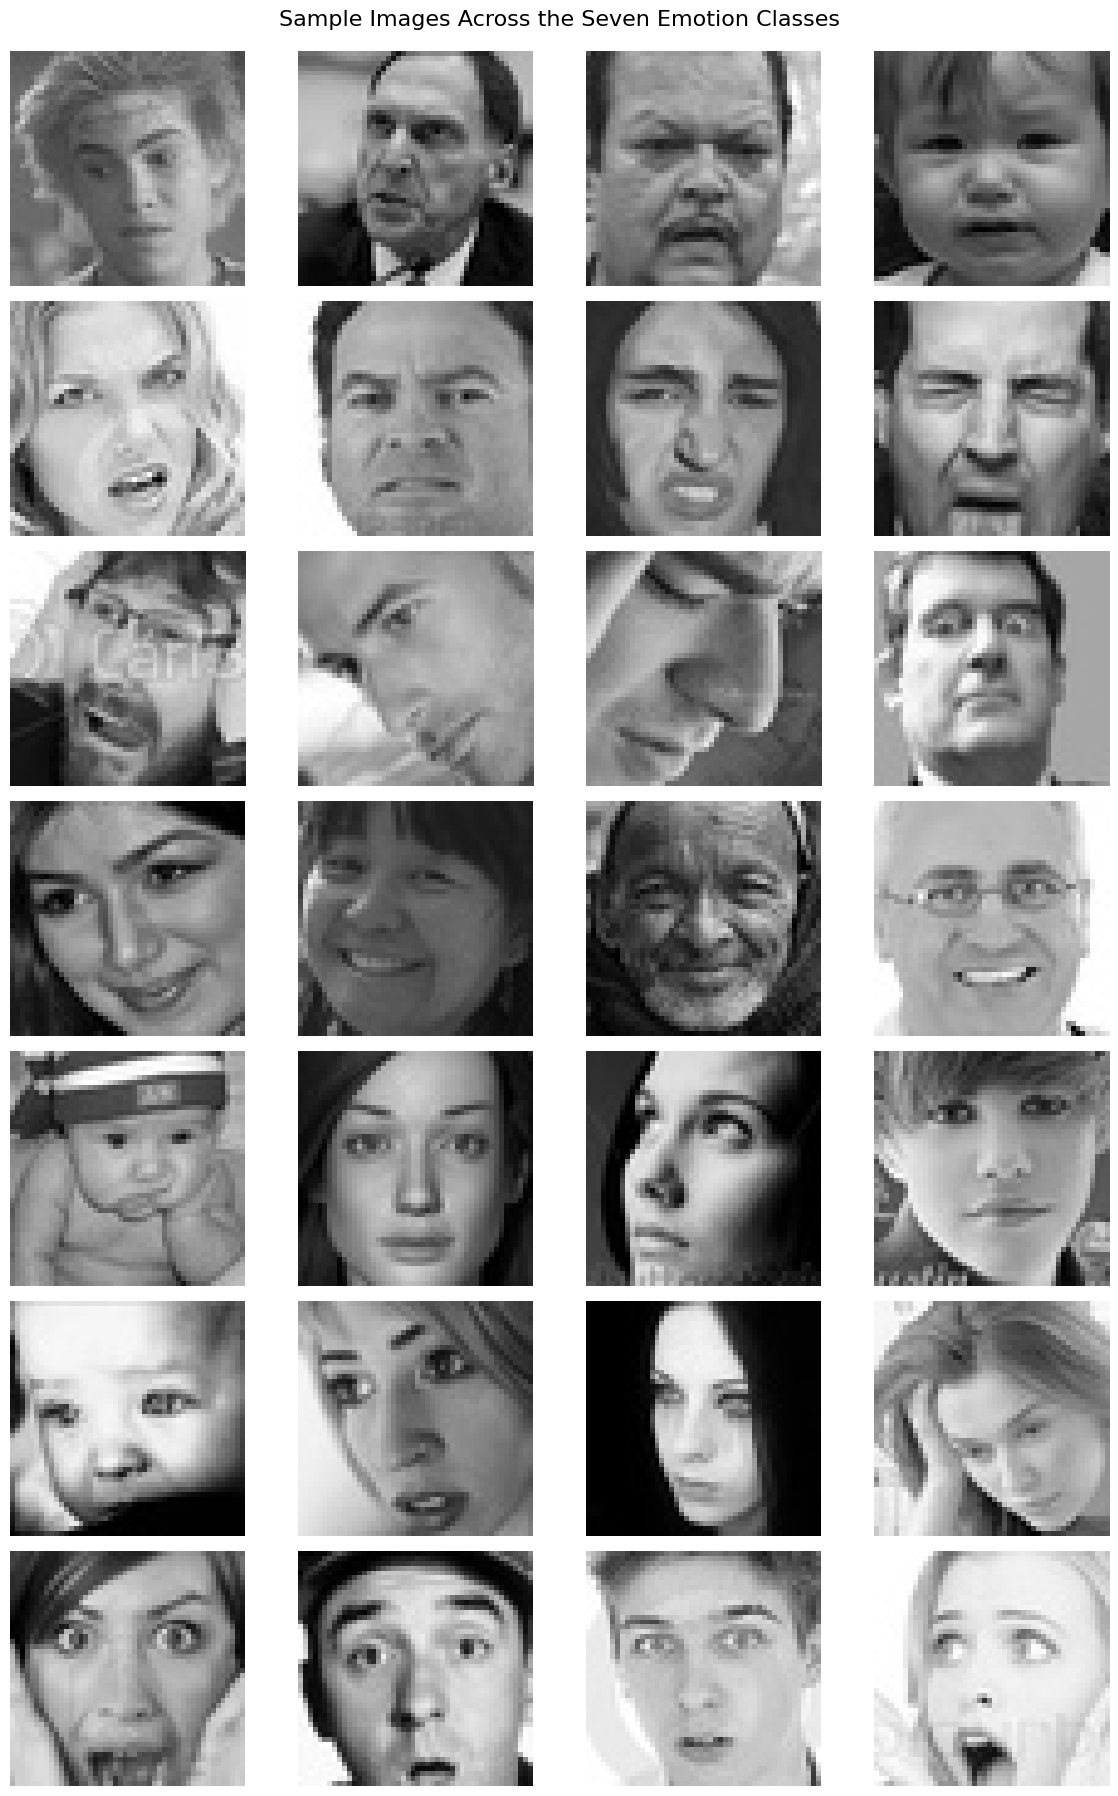

In [11]:
# Show different images from all seven emotion classes.
rng = np.random.default_rng(SEED)
images_per_class = 4
fig, axes = plt.subplots(len(EXPECTED_CLASSES), images_per_class, figsize=(12, 18))

for row_idx, emotion in enumerate(EXPECTED_CLASSES):
    emotion_df = train_df[train_df["label"] == emotion]
    n = min(images_per_class, len(emotion_df))
    selected = emotion_df.sample(n=n, random_state=SEED).reset_index(drop=True)

    for col_idx in range(images_per_class):
        ax = axes[row_idx, col_idx]
        ax.axis("off")
        if col_idx < n:
            img = Image.open(selected.loc[col_idx, "path"]).convert("RGB")
            ax.imshow(img)
            if col_idx == 0:
                ax.set_ylabel(emotion.title(), fontsize=11)
        else:
            ax.set_visible(False)

fig.suptitle("Sample Images Across the Seven Emotion Classes", fontsize=16, y=0.995)
plt.tight_layout()
plt.show()


### 6.2 Visualize the effect of basic augmentation

Only the same two simple augmentations used by the model are demonstrated here: horizontal flipping and small rotation.


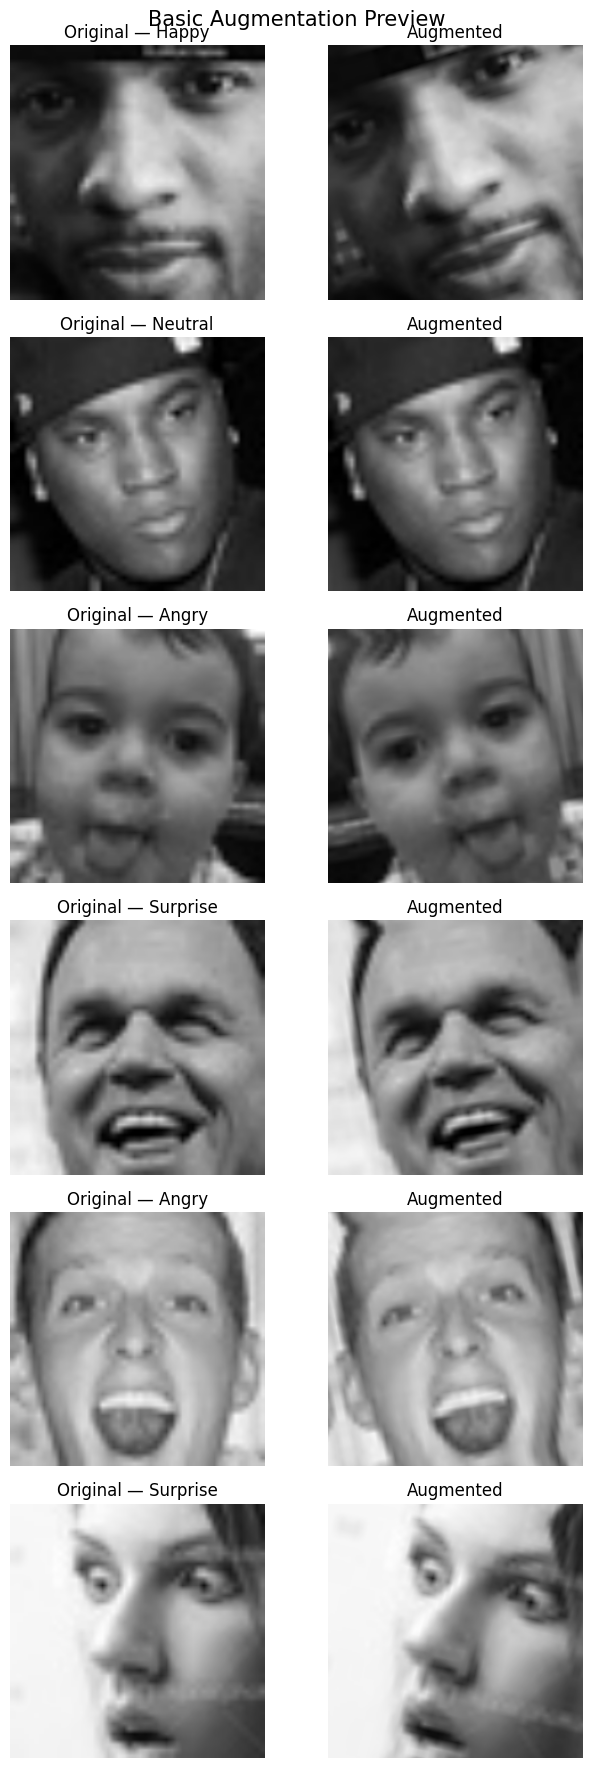

In [12]:
basic_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
], name="basic_augmentation_preview")

preview_batch = next(iter(train_ds.take(1)))
preview_images, preview_labels = preview_batch
preview_count = min(6, len(preview_images))
augmented_images = basic_augmentation(preview_images[:preview_count], training=True)

fig, axes = plt.subplots(preview_count, 2, figsize=(7, 3 * preview_count))
if preview_count == 1:
    axes = np.array([axes])

for i in range(preview_count):
    axes[i, 0].imshow(preview_images[i].numpy().astype(np.uint8))
    axes[i, 0].set_title(f"Original — {EXPECTED_CLASSES[int(preview_labels[i])].title()}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(tf.clip_by_value(augmented_images[i], 0, 255).numpy().astype(np.uint8))
    axes[i, 1].set_title("Augmented")
    axes[i, 1].axis("off")

plt.suptitle("Basic Augmentation Preview", fontsize=15)
plt.tight_layout()
plt.show()


## 7. EfficientNetB0 transfer-learning architecture

Why EfficientNetB0:
- pretrained ImageNet features reduce the amount of training required from scratch
- the backbone is compact enough for Colab experiments
- the model can be fine-tuned for the seven emotion classes

The model pipeline is:

**Input image → basic augmentation → EfficientNetB0 backbone → Global Average Pooling → Dropout → Dense layer → 7-class Softmax**


In [13]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

basic_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
], name="basic_augmentation")

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    name="efficientnetb0"
)

base_model.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")
x = basic_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pool")(x)
x = layers.Dropout(0.30, name="dropout")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
outputs = layers.Dense(
    len(EXPECTED_CLASSES),
    activation="softmax",
    name="emotion_output"
)(x)

model = models.Model(inputs, outputs, name="DeepFER_EfficientNetB0")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DeepFER_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ basic_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_output (Dense)          │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,442 (16.08 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 8. Training — Phase 1: frozen backbone

The callbacks stop training when validation performance stops improving and reduce the learning rate when convergence stalls.


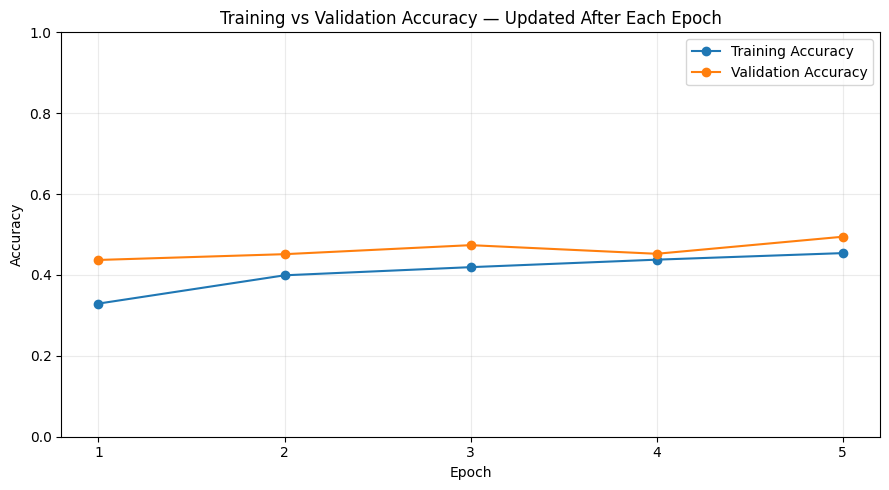


Epoch 5: val_accuracy improved from 0.47371 to 0.49455, saving model to /content/deepfer_head_best.keras

Epoch 5: finished saving model to /content/deepfer_head_best.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 61s 185ms/step - accuracy: 0.4540 - loss: 1.3980 - val_accuracy: 0.4945 - val_loss: 1.3546 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 5.


In [14]:
CHECKPOINT_HEAD = "/content/deepfer_head_best.keras"

class LiveAccuracyPlot(tf.keras.callbacks.Callback):
    """Refresh the training/validation accuracy chart after every epoch in Colab."""
    def on_train_begin(self, logs=None):
        self.train_acc = []
        self.val_acc = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.train_acc.append(float(logs.get("accuracy", np.nan)))
        self.val_acc.append(float(logs.get("val_accuracy", np.nan)))

        clear_output(wait=True)
        plt.figure(figsize=(9, 5))
        epochs = range(1, len(self.train_acc) + 1)
        plt.plot(epochs, self.train_acc, marker="o", label="Training Accuracy")
        plt.plot(epochs, self.val_acc, marker="o", label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Training vs Validation Accuracy — Updated After Each Epoch")
        plt.xticks(list(epochs))
        plt.ylim(0, 1)
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

callbacks_head = [
    LiveAccuracyPlot(),
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_HEAD, monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=2, restore_best_weights=True, mode="max", verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=1, min_lr=1e-7, verbose=1
    )
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_head,
    verbose=1
)


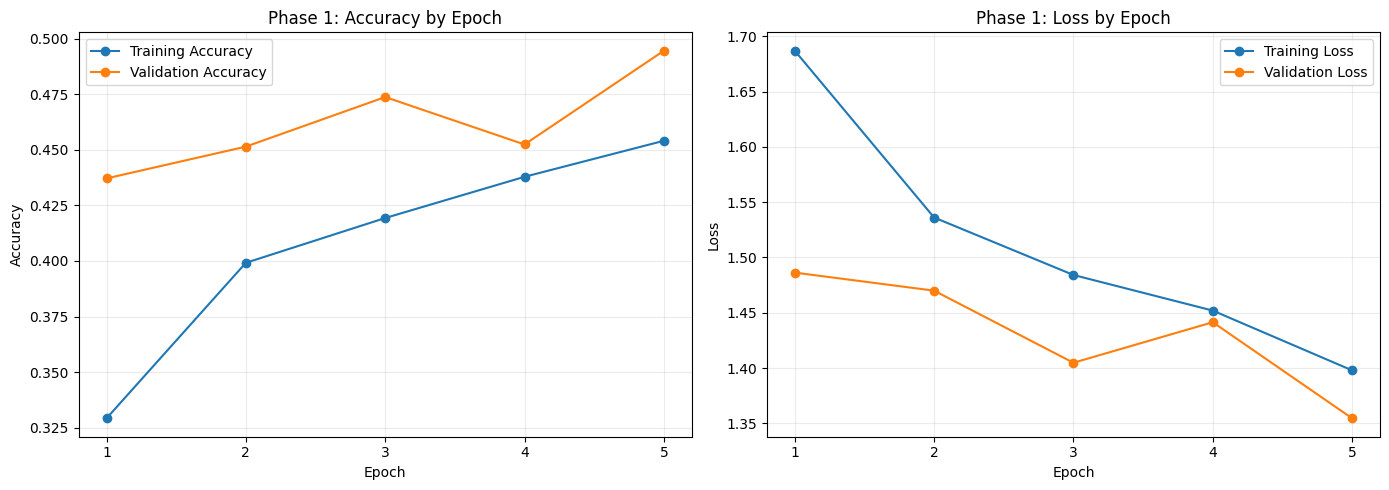

In [15]:
# Final line charts for the first training phase.
def plot_accuracy_and_loss(history, title_prefix="Training"):
    hist = pd.DataFrame(history.history)
    epochs = range(1, len(hist) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, hist["accuracy"], marker="o", label="Training Accuracy")
    axes[0].plot(epochs, hist["val_accuracy"], marker="o", label="Validation Accuracy")
    axes[0].set_title(f"{title_prefix}: Accuracy by Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xticks(list(epochs))
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(epochs, hist["loss"], marker="o", label="Training Loss")
    axes[1].plot(epochs, hist["val_loss"], marker="o", label="Validation Loss")
    axes[1].set_title(f"{title_prefix}: Loss by Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_xticks(list(epochs))
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_accuracy_and_loss(history_head, "Phase 1")


## 9. Training — Phase 2: fine-tuning

Only the final part of the EfficientNetB0 backbone is made trainable. Batch-normalization layers remain frozen, which helps stabilize fine-tuning on a moderately sized dataset.


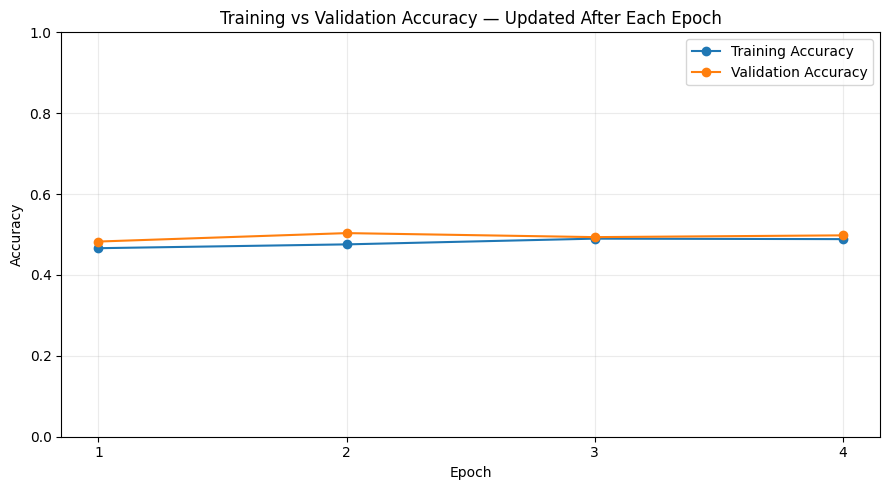


Epoch 4: val_accuracy did not improve from 0.50351
301/301 ━━━━━━━━━━━━━━━━━━━━ 65s 198ms/step - accuracy: 0.4886 - loss: 1.3032 - val_accuracy: 0.4979 - val_loss: 1.3272 - learning_rate: 3.0000e-06
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


In [16]:
# Fine-tune the final portion of EfficientNetB0.
base_model.trainable = True

# Freeze earlier layers and all BatchNormalization layers.
fine_tune_from = max(0, len(base_model.layers) - 30)

for idx, layer in enumerate(base_model.layers):
    if idx < fine_tune_from or isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

trainable_count = sum(int(layer.trainable) for layer in model.layers)
print("Trainable layers after fine-tuning setup:", trainable_count)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

CHECKPOINT_FINE = "/content/deepfer_finetuned_best.keras"

callbacks_fine = [
    LiveAccuracyPlot(),
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_FINE,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-8,
        verbose=1
    )
]

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_fine,
    verbose=1
)


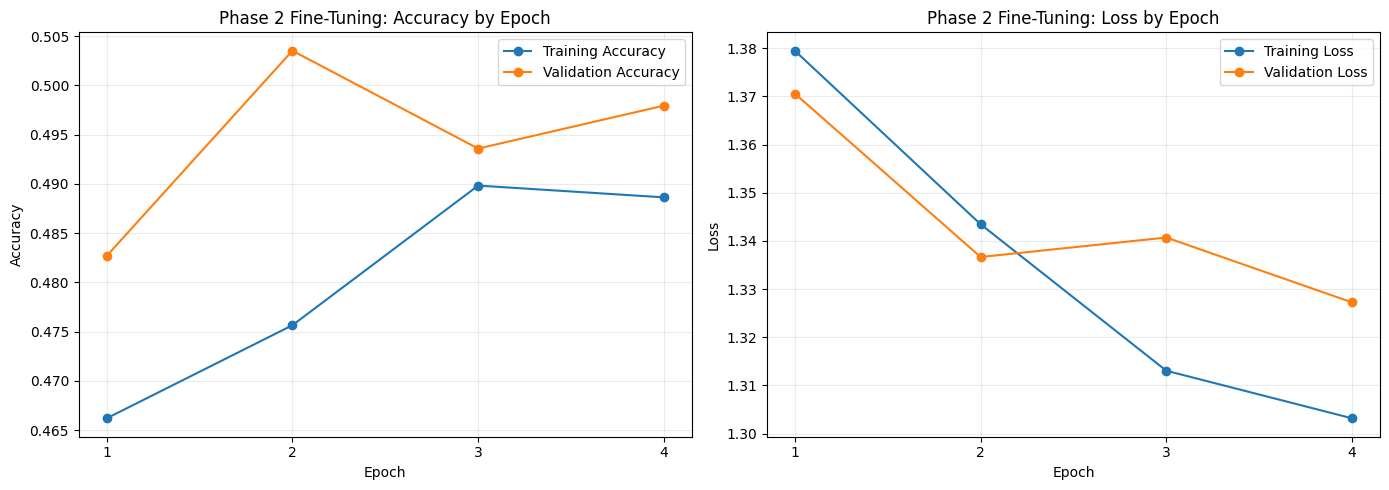

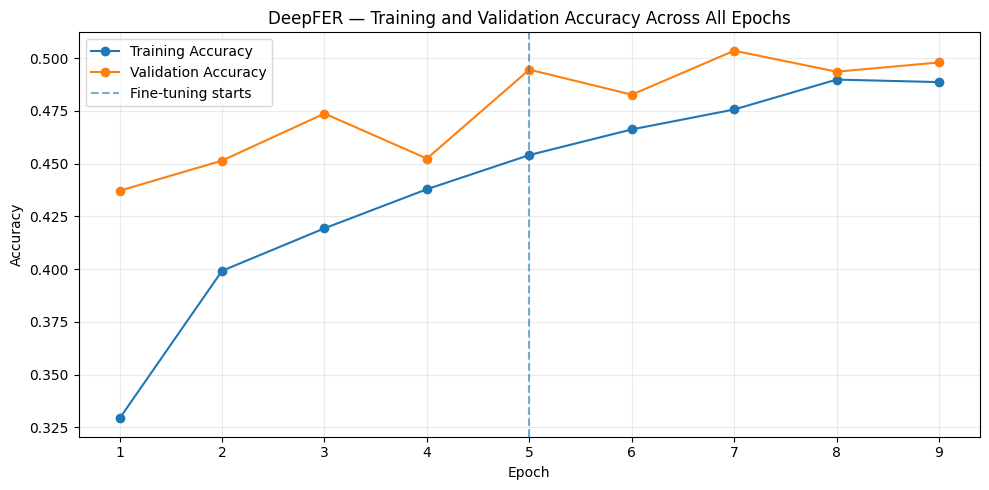

In [17]:
plot_accuracy_and_loss(history_fine, "Phase 2 Fine-Tuning")

# Combined accuracy chart across both phases for the final presentation.
head_hist = history_head.history
fine_hist = history_fine.history

combined_train_acc = head_hist["accuracy"] + fine_hist["accuracy"]
combined_val_acc = head_hist["val_accuracy"] + fine_hist["val_accuracy"]
combined_epochs = range(1, len(combined_train_acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(combined_epochs, combined_train_acc, marker="o", label="Training Accuracy")
plt.plot(combined_epochs, combined_val_acc, marker="o", label="Validation Accuracy")
plt.axvline(len(head_hist["accuracy"]), linestyle="--", alpha=0.6, label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DeepFER — Training and Validation Accuracy Across All Epochs")
plt.xticks(list(combined_epochs))
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


### Presentation-ready visual outputs

At this point the notebook has already produced:

- a class-distribution chart
- multiple example images from **all seven emotions**
- original vs augmented image comparisons
- a live **training vs validation accuracy** line chart after every epoch
- final training/validation accuracy and loss curves

These outputs directly support the dataset, preprocessing, training, and evaluation sections of the project presentation.


## 10. Final test-set evaluation

The test set was not used to tune the training process. We report:

- Accuracy
- Macro precision / recall / F1
- Weighted precision / recall / F1
- Per-class precision, recall, and F1
- Confusion matrix

For an imbalanced seven-class problem, macro F1 is especially useful because it gives each class equal importance.


In [18]:
# Final predictions on the untouched test set.
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy().tolist())
y_true = np.array(y_true)

y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

metrics_summary = {
    "accuracy": accuracy_score(y_true, y_pred),
    "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
}

print("Final test metrics")
for k, v in metrics_summary.items():
    print(f"{k:>20}: {v:.4f}")

print("\nClassification report")
report = classification_report(
    y_true,
    y_pred,
    target_names=EXPECTED_CLASSES,
    digits=4,
    zero_division=0
)
print(report)


65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step
Final test metrics
            accuracy: 0.5155
     macro_precision: 0.4605
        macro_recall: 0.5006
            macro_f1: 0.4517
  weighted_precision: 0.5317
     weighted_recall: 0.5155
         weighted_f1: 0.5128

Classification report
              precision    recall  f1-score   support

       angry     0.4678    0.3415    0.3948       574
     disgust     0.0924    0.5000    0.1560        56
        fear     0.4314    0.2260    0.2966       584
       happy     0.7215    0.7181    0.7198      1057
     neutral     0.4773    0.6192    0.5391       730
         sad     0.4428    0.3683    0.4021       725
    surprise     0.5904    0.7313    0.6533       402

    accuracy                         0.5155      4128
   macro avg     0.4605    0.5006    0.4517      4128
weighted avg     0.5317    0.5155    0.5128      4128



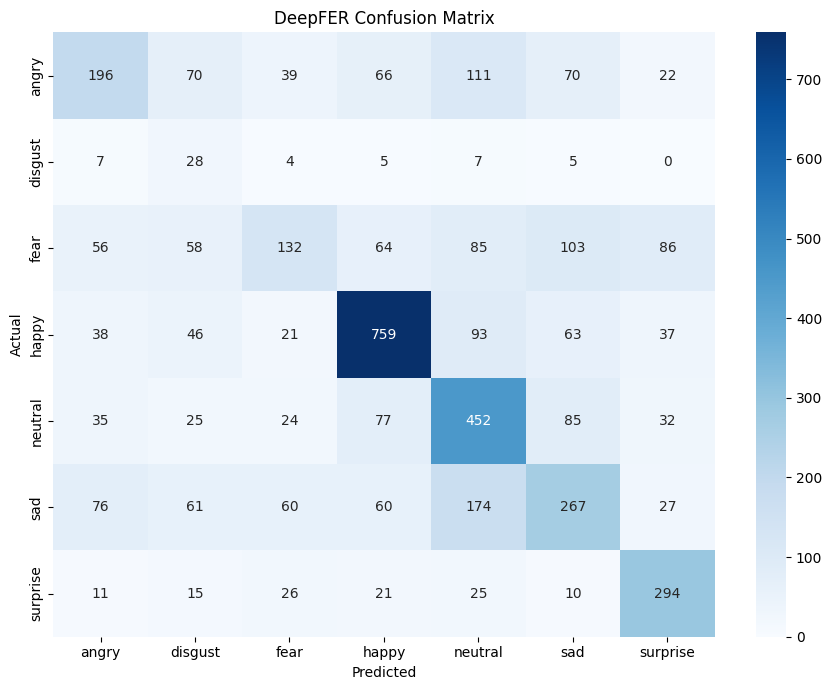

In [19]:
# Confusion matrix.
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(EXPECTED_CLASSES)))

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=EXPECTED_CLASSES,
    yticklabels=EXPECTED_CLASSES
)
plt.title("DeepFER Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 11. Error analysis

Common error patterns are expected when expressions share visual cues, for example:

- fear ↔ surprise,
- angry ↔ disgust,
- sad ↔ neutral.

The next cells identify the strongest off-diagonal confusion pairs and show representative misclassified examples.


In [20]:
# Show the most frequent confusion pairs.
pairs = []
for actual_idx in range(len(EXPECTED_CLASSES)):
    for pred_idx in range(len(EXPECTED_CLASSES)):
        if actual_idx != pred_idx and cm[actual_idx, pred_idx] > 0:
            pairs.append({
                "actual": EXPECTED_CLASSES[actual_idx],
                "predicted": EXPECTED_CLASSES[pred_idx],
                "count": int(cm[actual_idx, pred_idx])
            })

confusion_df = pd.DataFrame(pairs).sort_values("count", ascending=False)

print("Top confusion pairs:")
display(confusion_df.head(10))


Top confusion pairs:


,actual,predicted,count
33,sad,neutral,174
3,angry,neutral,111
15,fear,sad,103
20,happy,neutral,93
16,fear,surprise,86
14,fear,neutral,85
27,neutral,sad,85
26,neutral,happy,77
29,sad,angry,76
4,angry,sad,70


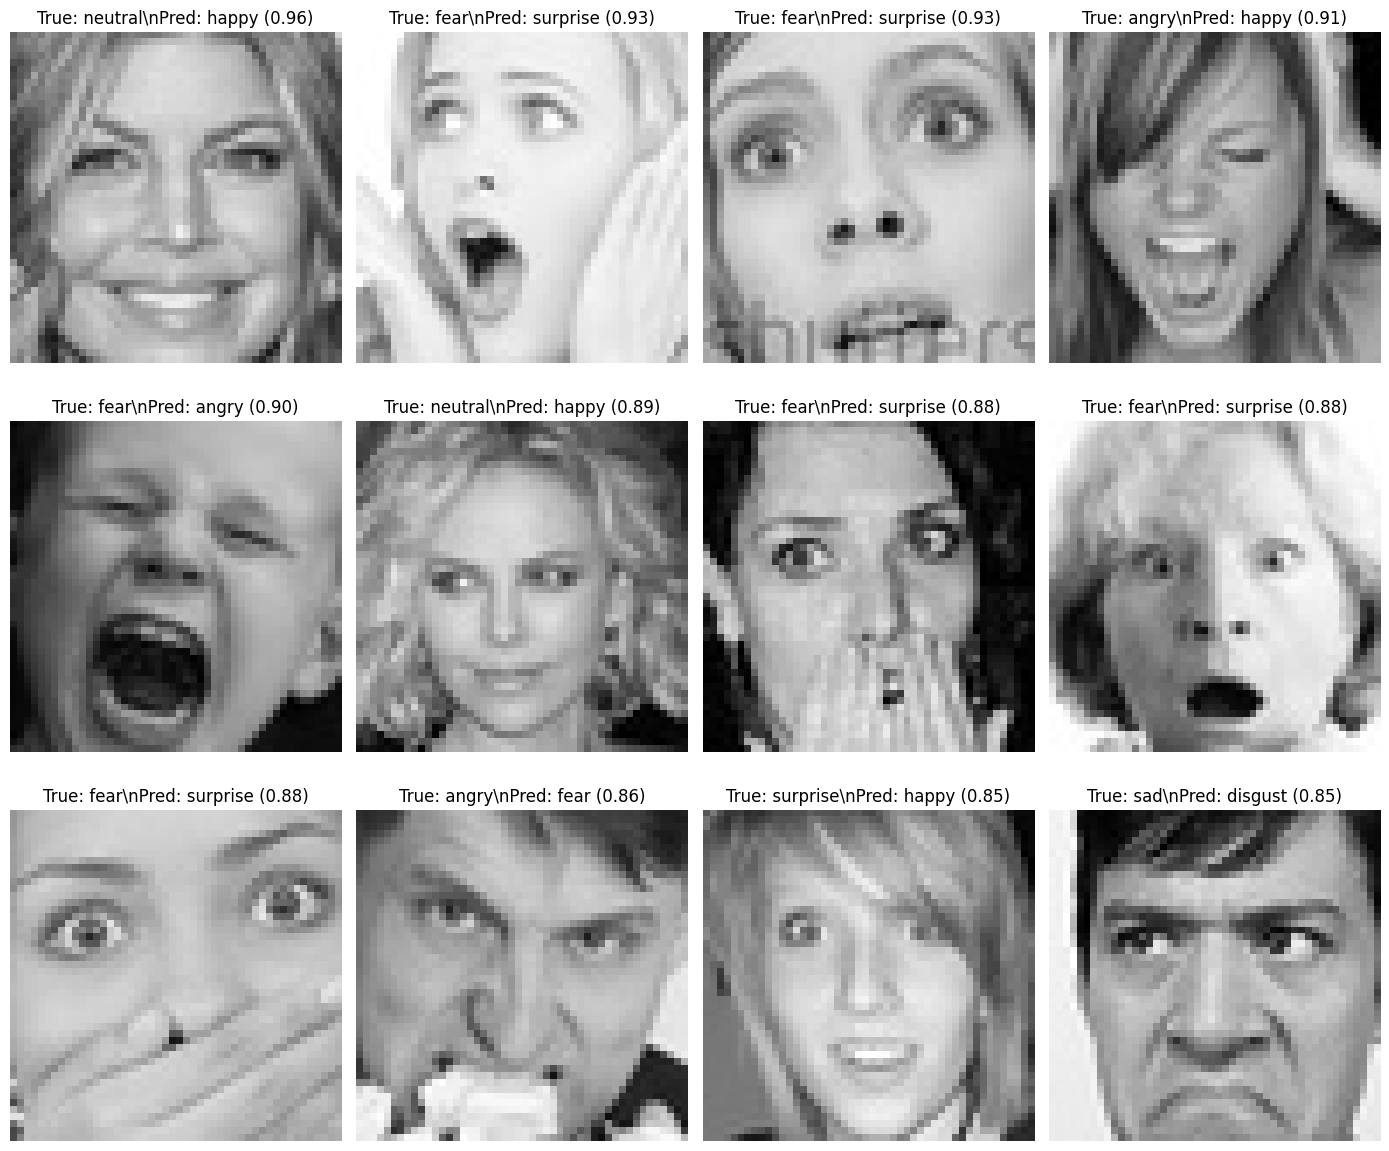

In [21]:
# Display representative misclassified test samples.
test_eval = test_df.copy()
test_eval["true_id"] = test_eval["label"].map(label_to_id)
test_eval["pred_id"] = y_pred
test_eval["pred_label"] = [EXPECTED_CLASSES[i] for i in y_pred]
test_eval["confidence"] = y_prob.max(axis=1)

misclassified = test_eval[test_eval["true_id"] != test_eval["pred_id"]].copy()
misclassified = misclassified.sort_values("confidence", ascending=False).head(12)

plt.figure(figsize=(14, 12))
for i, (_, row) in enumerate(misclassified.iterrows(), start=1):
    img = Image.open(row["path"]).convert("RGB")
    ax = plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.title(
        f"True: {row['label']}\\nPred: {row['pred_label']} ({row['confidence']:.2f})"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


## 12. Grad-CAM interpretability

Grad-CAM highlights image regions that contribute most strongly to the predicted class. This is useful for debugging whether the network is focusing on the facial region rather than irrelevant background pixels.

The visual explanation is **not** a causal explanation of emotion; it is only an attribution-style visualization of model activations.


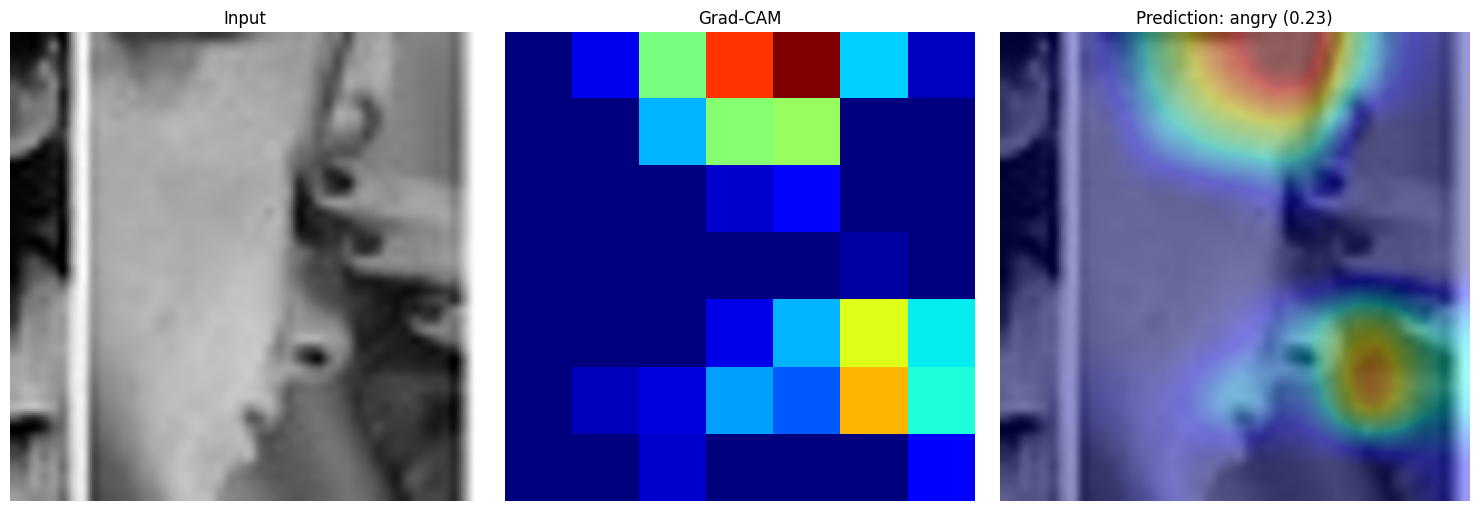

In [26]:
def make_gradcam_heatmap(img_array, model, conv_layer_name="top_conv"):
    """
    img_array: float32 array shaped (1, H, W, 3), raw 0-255 pixel values.
    """
    # Create a sub-model that explicitly routes the backbone's inputs to outputs
    backbone = model.get_layer("efficientnetb0")

    # The backbone itself is a functional model. We can wrap the backbone's sub-graph
    # or build the grad_model from the backbone's input tensor directly to bypass model.inputs wrapper conflicts
    backbone_grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[backbone.get_layer(conv_layer_name).output, backbone.output]
    )

    # Run the model's pipeline layers sequentially on the image
    # Input -> basic_augmentation
    augmented_img = model.get_layer("basic_augmentation")(img_array, training=False)

    with tf.GradientTape() as tape:
        # backbone forward pass
        conv_outputs, backbone_features = backbone_grad_model(augmented_img)

        # Dense head forward pass
        x = model.get_layer("global_average_pool")(backbone_features)
        x = model.get_layer("dropout")(x, training=False)
        x = model.get_layer("dense_128")(x)
        predictions = model.get_layer("emotion_output")(x)

        class_index = tf.argmax(predictions[0])
        class_score = predictions[:, class_index]

    # Calculate gradients of the class score with respect to conv_outputs
    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_value + tf.keras.backend.epsilon())

    return heatmap.numpy(), int(class_index), float(tf.reduce_max(predictions[0]))

# Use the first test image for a visual explanation.
example_path = test_df.iloc[0]["path"]
example_pil = Image.open(example_path).convert("RGB").resize(IMG_SIZE)
example_arr = np.asarray(example_pil, dtype=np.float32)[None, ...]

heatmap, pred_index, pred_conf = make_gradcam_heatmap(example_arr, model)

heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_pil = Image.fromarray(heatmap_uint8).resize(IMG_SIZE)
heatmap_color = np.asarray(plt.get_cmap("jet")(np.asarray(heatmap_pil) / 255.0)[..., :3] * 255, dtype=np.uint8)

overlay = (
    0.60 * np.asarray(example_pil, dtype=np.float32)
    + 0.40 * heatmap_color.astype(np.float32)
).clip(0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(example_pil)
axes[0].set_title("Input")
axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM")
axes[2].imshow(overlay)
axes[2].set_title(
    f"Prediction: {EXPECTED_CLASSES[pred_index]} ({pred_conf:.2f})"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 13. Save the trained model and metadata

The saved package is self-contained for the Streamlit demo:

```text
/content/deepfer_streamlit/
    deepfer_model.keras
    class_names.json
    app.py
    requirements.txt
```


In [27]:
APP_DIR = Path("/content/deepfer_streamlit")
APP_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = APP_DIR / "deepfer_model.keras"
CLASS_NAMES_PATH = APP_DIR / "class_names.json"

model.save(MODEL_PATH)

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(EXPECTED_CLASSES, f, indent=2)

with open(APP_DIR / "metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved:", MODEL_PATH)
print("Saved:", CLASS_NAMES_PATH)


Saved: /content/deepfer_streamlit/deepfer_model.keras
Saved: /content/deepfer_streamlit/class_names.json


## 14. Generate the Streamlit UI

The app provides:

- Upload-an-image inference
- Browser camera capture through `st.camera_input`
- Top-3 predicted expression classes
- Confidence visualization
- Optional Grad-CAM visualization
- A project/ethics information panel

The model is loaded once with `st.cache_resource` for lower inference latency.


In [28]:
%%writefile /content/deepfer_streamlit/app.py
import json
from pathlib import Path

import numpy as np
import streamlit as st
import tensorflow as tf
from PIL import Image

BASE_DIR = Path(__file__).resolve().parent
MODEL_PATH = BASE_DIR / "deepfer_model.keras"
CLASS_NAMES_PATH = BASE_DIR / "class_names.json"

IMG_SIZE = (224, 224)

st.set_page_config(
    page_title="DeepFER — Facial Emotion Recognition",
    page_icon="🙂",
    layout="wide"
)

@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)

@st.cache_data
def load_class_names():
    with open(CLASS_NAMES_PATH, "r") as f:
        return json.load(f)

model = load_model()
class_names = load_class_names()

def preprocess_image(image):
    image = image.convert("RGB").resize(IMG_SIZE)
    arr = np.asarray(image, dtype=np.float32)
    return image, arr

def predict(image):
    resized, arr = preprocess_image(image)
    probs = model.predict(arr[None, ...], verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:3]
    return resized, probs, top_indices

def gradcam_overlay(image_array, conv_layer_name="top_conv"):
    backbone = model.get_layer("efficientnetb0")
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            backbone.get_layer(conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_array[None, ...])
        class_idx = tf.argmax(predictions[0])
        class_score = predictions[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    heatmap = heatmap.numpy()

    heatmap_img = Image.fromarray(np.uint8(255 * heatmap)).resize(IMG_SIZE)
    heatmap_rgb = np.asarray(
        tf.keras.utils.array_to_img(
            tf.keras.applications.imagenet_utils.preprocess_input(
                np.asarray(heatmap_img.convert("RGB"), dtype=np.float32)
            )
        )
    )

    # Simpler red-channel intensity overlay for robustness.
    hm = np.asarray(heatmap_img, dtype=np.float32) / 255.0
    base = image_array.astype(np.float32) / 255.0
    overlay = np.empty_like(base)
    overlay[..., 0] = np.clip(base[..., 0] * 0.55 + hm * 0.45, 0, 1)
    overlay[..., 1] = base[..., 1] * 0.65
    overlay[..., 2] = base[..., 2] * 0.65

    return overlay

st.title("DeepFER")
st.caption("Facial-expression recognition using EfficientNetB0 transfer learning")

st.info(
    "This model predicts visual expression categories from an image. "
    "It is not a diagnostic tool and should not be used to infer a person's "
    "mental-health condition or internal emotional state."
)

tab_upload, tab_camera, tab_about = st.tabs(
    ["Upload Image", "Camera", "Project Details"]
)

with tab_upload:
    uploaded_file = st.file_uploader(
        "Upload a face image",
        type=["jpg", "jpeg", "png"]
    )

    if uploaded_file:
        image = Image.open(uploaded_file)
        resized, probs, top_indices = predict(image)

        col1, col2 = st.columns([1, 1])

        with col1:
            st.image(image, caption="Input image", use_container_width=True)

        with col2:
            best_idx = int(top_indices[0])
            st.subheader(f"Predicted expression: {class_names[best_idx].title()}")
            st.metric("Model confidence", f"{probs[best_idx] * 100:.2f}%")

            top_table = {
                "Expression": [class_names[i].title() for i in top_indices],
                "Confidence": [f"{probs[i] * 100:.2f}%" for i in top_indices]
            }
            st.table(top_table)

            st.bar_chart(
                {class_names[i].title(): float(probs[i]) for i in top_indices}
            )

        show_gradcam = st.checkbox("Show Grad-CAM explanation", value=True)

        if show_gradcam:
            try:
                arr = np.asarray(resized, dtype=np.float32)
                overlay = gradcam_overlay(arr)
                st.image(
                    overlay,
                    caption="Grad-CAM activation overlay",
                    use_container_width=True
                )
            except Exception as exc:
                st.warning(f"Grad-CAM could not be generated for this model: {exc}")

with tab_camera:
    st.write("Capture a face image using your browser camera and run inference.")

    camera_file = st.camera_input("Take a photo")

    if camera_file:
        image = Image.open(camera_file)
        resized, probs, top_indices = predict(image)

        best_idx = int(top_indices[0])
        st.image(image, caption="Captured frame", use_container_width=True)
        st.success(
            f"Predicted expression: {class_names[best_idx].title()} "
            f"({probs[best_idx] * 100:.2f}%)"
        )

        st.write("Top 3 predictions")
        for idx in top_indices:
            st.write(
                f"**{class_names[idx].title()}** — "
                f"{probs[idx] * 100:.2f}%"
            )

with tab_about:
    st.subheader("DeepFER project")
    st.write(
        "DeepFER uses image preprocessing, augmentation, EfficientNetB0 "
        "transfer learning, class-weighted training, fine-tuning, and "
        "post-training error analysis."
    )

    st.subheader("Predicted classes")
    st.write(", ".join(name.title() for name in class_names))

    st.subheader("Real-world considerations")
    st.write(
        "Performance can change with lighting, camera quality, occlusion, "
        "pose, demographic composition, and domain shift. The model should "
        "be validated on representative deployment data before production use."
    )

st.divider()
st.caption("DeepFER • CNN / Transfer Learning • Streamlit")


Writing /content/deepfer_streamlit/app.py


In [29]:
# Minimal runtime requirements for the Streamlit demo.
requirements_text = """streamlit
tensorflow
pillow
numpy
"""
(APP_DIR / "requirements.txt").write_text(requirements_text)
print((APP_DIR / "requirements.txt").read_text())


streamlit
tensorflow
pillow
numpy



## 15. Launch Streamlit from Google Colab

The next cell starts Streamlit on port 8501. The following cell creates a temporary public tunnel using localtunnel.

Keep the Streamlit process running while you use the demo URL.


In [30]:
# Start Streamlit in the background.
import subprocess, time, os

streamlit_log = open("/content/streamlit.log", "w")

streamlit_process = subprocess.Popen(
    [
        "streamlit", "run", str(APP_DIR / "app.py"),
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.headless", "true"
    ],
    stdout=streamlit_log,
    stderr=subprocess.STDOUT
)

time.sleep(8)

print("Streamlit process PID:", streamlit_process.pid)
print("Log file: /content/streamlit.log")
print("\nLast log lines:\n")
try:
    print(Path("/content/streamlit.log").read_text()[-3000:])
except Exception as exc:
    print("Could not read log yet:", exc)


Streamlit process PID: 9975
Log file: /content/streamlit.log

Last log lines:



2026-09-22 13:33:48.470 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.228.25.246:8501




### Public URL

Run the next cell and open the generated `https://...loca.lt` URL.


In [31]:
# Temporary public tunnel for the Colab Streamlit app.
# localtunnel is suitable for demos; it is not a production hosting solution.
!npx --yes localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://calm-years-dress.loca.lt
^C


## 16. Optional: package the Streamlit app and artifacts

This creates a ZIP containing the trained model, class names, metrics, app, and requirements so the demo can be moved outside Colab.


In [32]:
# Package the trained Streamlit app.
artifact_zip = "/content/DeepFER_Streamlit_Demo.zip"

if os.path.exists(artifact_zip):
    os.remove(artifact_zip)

shutil.make_archive(
    base_name="/content/DeepFER_Streamlit_Demo",
    format="zip",
    root_dir=str(APP_DIR)
)

print("Created:", artifact_zip)


Created: /content/DeepFER_Streamlit_Demo.zip
